In [29]:
# ==========================================
# 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

In [30]:
# ==========================================
# 2. Loading
# ==========================================
df = pd.read_csv("/content/Fifa.csv")
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


# EDA

In [31]:
# Dataset Overview
print("Dataset Shape:", df.shape)

Dataset Shape: (19667, 9)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [33]:
# Basic Statistics
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [34]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [35]:
# Unique Values for Categorical Columns
print("Unique Countries:", df['Country'].nunique())
print("Unique Positions:", df['Position'].nunique())
print("Unique Teams:", df['Team'].nunique())
print("\nPosition Distribution:")
print(df['Position'].value_counts().head(10))

Unique Countries: 164
Unique Positions: 17
Unique Teams: 1009

Position Distribution:
Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
Name: count, dtype: int64


In [36]:
# Check for potential outliers in numerical columns
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
print("Outlier Detection (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")

Outlier Detection (using IQR method):
Age: 169 outliers
Overall_Rating: 146 outliers
Future Potential: 120 outliers
Value Per M$: 2390 outliers
Total_Stats Score: 788 outliers


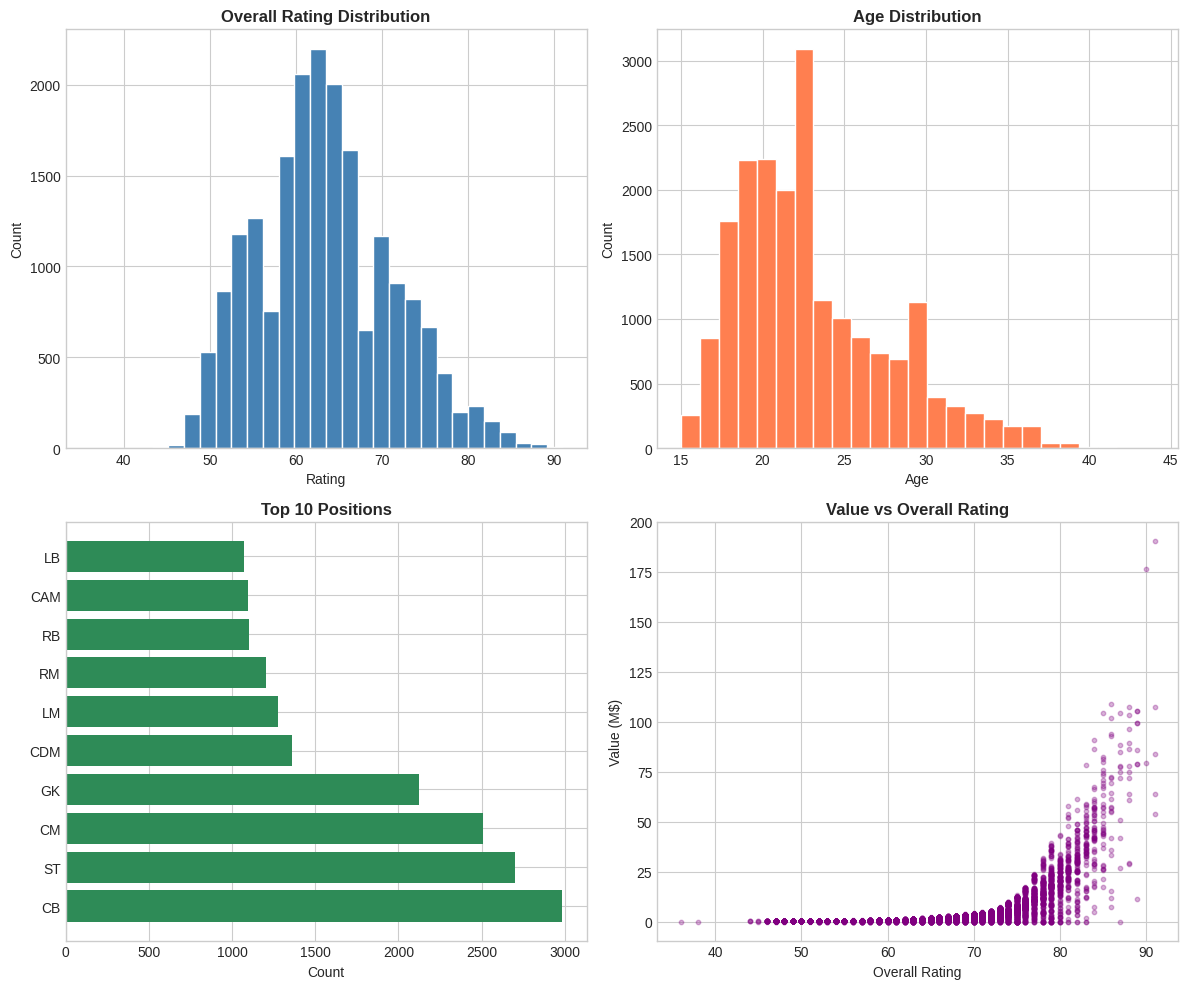

In [37]:

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Overall Rating Distribution
axes[0, 0].hist(df['Overall_Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Overall Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution
axes[0, 1].hist(df['Age'], bins=25, color='coral', edgecolor='white')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# 3. Top 10 Positions
pos_counts = df['Position'].value_counts().head(10)
axes[1, 0].barh(pos_counts.index, pos_counts.values, color='seagreen')
axes[1, 0].set_title('Top 10 Positions', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Value vs Overall Rating
axes[1, 1].scatter(df['Overall_Rating'], df['Value Per M$'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('Value vs Overall Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Rating')
axes[1, 1].set_ylabel('Value (M$)')

plt.tight_layout()
plt.show()

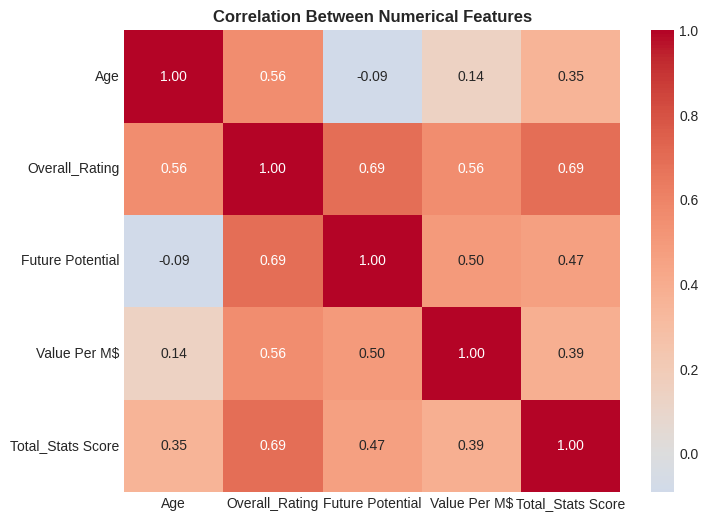

In [38]:
# Correlation Heatmap
numerical_df = df[['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']]
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=12, fontweight='bold')
plt.show()

# Preprocessing

In [39]:
# ── Classification target ────────────────────────────────────────────────────
def assign_tier(rating):
    if rating >= 85: return 'Elite'
    elif rating >= 75: return 'High'
    elif rating >= 65: return 'Mid'
    else: return 'Low'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

tier_order = ['Low', 'Mid', 'High', 'Elite']
df['Performance_Tier'] = pd.Categorical(df['Performance_Tier'],
                                        categories=tier_order, ordered=True)

print("Performance Tier distribution:")
print(df['Performance_Tier'].value_counts().sort_index())

# ── Regression target ────────────────────────────────────────────────────────
# Log-transform to handle right skew
df['Value_log'] = np.log1p(df['Value Per M$'])

Performance Tier distribution:
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


In [40]:
# Targets to exclude from X
REGRESSION_TARGET   = 'Value_log'          # log-transformed
CLASSIFICATION_TARGET = 'Performance_Tier'

TARGET_COLS = ['Value Per M$', 'Value_log',
               'Performance_Tier', 'Overall_Rating']  # Overall_Rating defines tiers

# Feature groups
num_features      = ['Age', 'Future Potential', 'Total_Stats Score']


low_card_cat  = ['Position']
high_card_cat = ['Country', 'Team']


num_features_reg = num_features + ['Overall_Rating']


num_features_clf = num_features

print("Numerical features (regression) :", num_features_reg)
print("Numerical features (classif.)   :", num_features_clf)
print("Low-cardinality categoricals    :", low_card_cat)
print("High-cardinality categoricals   :", high_card_cat)

Numerical features (regression) : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
Numerical features (classif.)   : ['Age', 'Future Potential', 'Total_Stats Score']
Low-cardinality categoricals    : ['Position']
High-cardinality categoricals   : ['Country', 'Team']


In [41]:
RANDOM_STATE = 42

# ── Features ─────────────────────────────────────────────────────────────────
all_features = num_features_reg + low_card_cat

X = df[all_features].copy()
y_reg = df[REGRESSION_TARGET].copy()
y_clf = df[CLASSIFICATION_TARGET].copy()

# ── Stratified split (based on classification target) ────────────────────────
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"Test size  : {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print()
print("Tier distribution — train:")
print(y_clf_train.value_counts().sort_index())
print()
print("Tier distribution — test:")
print(y_clf_test.value_counts().sort_index())

Train size : 15,733  (80%)
Test size  : 3,934   (20%)

Tier distribution — train:
Performance_Tier
Low      9392
Mid      4899
High     1369
Elite      73
Name: count, dtype: int64

Tier distribution — test:
Performance_Tier
Low      2348
Mid      1225
High      342
Elite      19
Name: count, dtype: int64


In [42]:
# ── Sub-pipelines ──────────────────────────────────────────────────
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # robust to skew / outliers
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer for REGRESSION ─────────────────────────────────────────
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_reg),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'   # silently drops any column not listed
)

# ── ColumnTransformer for CLASSIFICATION ─────────────────────────────────────
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_clf),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'
)

print("Preprocessors defined ✓")
print()
print("Regression  preprocessor inputs :", num_features_reg + low_card_cat)
print("Classification preprocessor inputs:", num_features_clf + low_card_cat)

Preprocessors defined ✓

Regression  preprocessor inputs : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating', 'Position']
Classification preprocessor inputs: ['Age', 'Future Potential', 'Total_Stats Score', 'Position']


In [43]:
# ── Fit on TRAIN only  ──────────────────────────────────────────────
X_train_reg = preprocessor_reg.fit_transform(X_train)
X_test_reg  = preprocessor_reg.transform(X_test)

X_train_clf = preprocessor_clf.fit_transform(X_train)
X_test_clf  = preprocessor_clf.transform(X_test)

# ── Feature names after encoding ──────────────────────────────────────────────
feature_names_reg = preprocessor_reg.get_feature_names_out()
feature_names_clf = preprocessor_clf.get_feature_names_out()

print("=== Regression ===")
print(f"  X_train shape : {X_train_reg.shape}")

print()
print("=== Classification ===")
print(f"  X_train shape : {X_train_clf.shape}")

=== Regression ===
  X_train shape : (15733, 20)

=== Classification ===
  X_train shape : (15733, 19)


# Polynomial Regression & Regularization


In [44]:
# use num_features_reg defined
target_col = 'Value Per M$'
print("\n--- Starting Polynomial Regression Module ---")


--- Starting Polynomial Regression Module ---


In [45]:
# Preprocessing Function for Polynomial Regression
def preprocess_for_regression(X_train, X_test, y_train, y_test, degree):
    """
    Prepares data for Polynomial Regression.
    - Assumes y_train and y_test are already log-transformed.
    - Handles Polynomial Features + Scaling for Numerical.
    - Handles One-Hot Encoding for Categorical (Position).
    """

    # 1. Define features using defined (num_features_reg)
    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    # 2. Process Numerical Features (Polynomial + Scaling)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_array = poly.fit_transform(X_train[polynomial_features])
    X_test_poly_array = poly.transform(X_test[polynomial_features])

    poly_feature_names = poly.get_feature_names_out(polynomial_features)

    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly_array)
    X_test_poly_scaled = scaler.transform(X_test_poly_array)

    # Convert to DataFrame
    X_train_poly_df = pd.DataFrame(X_train_poly_scaled, columns=poly_feature_names, index=X_train.index)
    X_test_poly_df = pd.DataFrame(X_test_poly_scaled, columns=poly_feature_names, index=X_test.index)

    # 3. Process Categorical Features (One-Hot Encoding)
    if categorical_features:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        X_train_cat_array = ohe.fit_transform(X_train[categorical_features])
        X_test_cat_array = ohe.transform(X_test[categorical_features])

        cat_feature_names = ohe.get_feature_names_out(categorical_features)

        X_train_cat_df = pd.DataFrame(X_train_cat_array, columns=cat_feature_names, index=X_train.index)
        X_test_cat_df = pd.DataFrame(X_test_cat_array, columns=cat_feature_names, index=X_test.index)
    else:
        X_train_cat_df = pd.DataFrame(index=X_train.index)
        X_test_cat_df = pd.DataFrame(index=X_test.index)
        cat_feature_names = []

    # 4. Merge
    X_train_final = pd.concat([X_train_poly_df, X_train_cat_df], axis=1)
    X_test_final = pd.concat([X_test_poly_df, X_test_cat_df], axis=1)

    all_feature_names = list(poly_feature_names) + list(cat_feature_names)

    return X_train_final.values, X_test_final.values, y_train, y_test, all_feature_names

In [46]:
def fit_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Inverse transform to original scale
    y_train_original = np.expm1(y_train)
    y_test_original = np.expm1(y_test)
    y_pred_train_original = np.expm1(y_pred_train)
    y_pred_test_original = np.expm1(y_pred_test)

    # Clip negatives
    y_pred_train_original = np.maximum(0, y_pred_train_original)
    y_pred_test_original = np.maximum(0, y_pred_test_original)

    # Metrics
    r2_train_log = r2_score(y_train, y_pred_train)
    r2_test_log = r2_score(y_test, y_pred_test)
    r2_train_orig = r2_score(y_train_original, y_pred_train_original)
    r2_test_orig = r2_score(y_test_original, y_pred_test_original)

    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_pred_train_original))
    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
    mae_train = mean_absolute_error(y_train_original, y_pred_train_original)
    mae_test = mean_absolute_error(y_test_original, y_pred_test_original)
    mse_train = mean_squared_error(y_train_original, y_pred_train_original)
    mse_test = mean_squared_error(y_test_original, y_pred_test_original)

    results = {
        'Train_R2_log': r2_train_log, 'Test_R2_log': r2_test_log,
        'Train_R2_orig': r2_train_orig, 'Test_R2_orig': r2_test_orig,
        'Train_RMSE': rmse_train, 'Test_RMSE': rmse_test,
        'Train_MAE': mae_train, 'Test_MAE': mae_test,
        'Train_MSE': mse_train, 'Test_MSE': mse_test
    }
    return results

In [47]:
def find_best_polynomial_degree(X_train, X_test, y_train, y_test, random_state):
    degrees = [1, 2, 3, 4, 5, 6]
    train_r2_log, test_r2_log = [], []
    train_r2_orig, test_r2_orig = [], []

    best_degree = 1
    best_test_r2_orig = -float('inf')
    results_records = []

    def _safe_format(value, threshold=1e10):
        if np.isnan(value) or np.isinf(value) or abs(value) > threshold:
            return "OVERFLOW"
        return value

    print("\n--- Polynomial Regression Experiment ---")

    for current_degree in degrees:
        X_train_poly, X_test_poly, y_train_proc, y_test_proc, _ = preprocess_for_regression(
            X_train, X_test, y_train, y_test, current_degree
        )
        model = LinearRegression()
        evaluation_metrics = fit_and_evaluate(model, X_train_poly, y_train_proc, X_test_poly, y_test_proc)

        train_r2_log.append(evaluation_metrics['Train_R2_log'])
        test_r2_log.append(evaluation_metrics['Test_R2_log'])
        train_r2_orig.append(evaluation_metrics['Train_R2_orig'])
        test_r2_orig.append(evaluation_metrics['Test_R2_orig'])

        results_records.append({
            'Degree': current_degree,
            'Test_R2_orig': _safe_format(evaluation_metrics['Test_R2_orig']),
            'Test_RMSE': _safe_format(evaluation_metrics['Test_RMSE'])
        })

        if current_degree == 1:
            print(f"Baseline (Degree=1): RMSE={evaluation_metrics['Test_RMSE']:.2f}")

        current_r2_orig = evaluation_metrics['Test_R2_orig']
        is_valid_r2 = not (np.isnan(current_r2_orig) or np.isinf(current_r2_orig) or current_r2_orig < -10.0)
        if is_valid_r2 and current_r2_orig > best_test_r2_orig:
            best_test_r2_orig = current_r2_orig
            best_degree = current_degree

    df_results = pd.DataFrame(results_records)
    print("\n" + df_results.to_string(index=False))

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_r2_log, 'o-', label='Train R² (log)')
    plt.plot(degrees, test_r2_log, 'o-', label='Test R² (log)')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R² Score (log space)')
    plt.title('Model Performance vs Degree')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest degree found: {best_degree}")

In [48]:
# Regularization Function
def find_best_regularization_alpha(X_train, X_test, y_train, y_test, best_degree, random_state):
    X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed, feature_names = preprocess_for_regression(
        X_train, X_test, y_train, y_test, best_degree
    )

    ridge_alphas = np.logspace(-10, 10, 40)
    lasso_alphas = np.logspace(-4, 1, 20)

    best_ridge_alpha, best_ridge_rmse = ridge_alphas[0], float('inf')
    best_lasso_alpha, best_lasso_rmse = lasso_alphas[0], float('inf')

    print("\n--- Ridge Regression ---")
    for alpha in ridge_alphas:
        model = Ridge(alpha=alpha, random_state=random_state)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_ridge_rmse:
            best_ridge_rmse = metrics['Test_RMSE']
            best_ridge_alpha = alpha

    print(f"Best Ridge Alpha: {best_ridge_alpha:.4f}, RMSE: {best_ridge_rmse:.4f}")

    print("\n--- Lasso Regression ---")
    for alpha in lasso_alphas:
        model = Lasso(alpha=alpha, random_state=random_state, max_iter=10000, tol=1e-3)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_lasso_rmse:
            best_lasso_rmse = metrics['Test_RMSE']
            best_lasso_alpha = alpha

    print(f"Best Lasso Alpha: {best_lasso_alpha:.4f}, RMSE: {best_lasso_rmse:.4f}")

    return best_ridge_alpha, best_lasso_alpha, best_ridge_rmse, best_lasso_rmse

In [49]:
# Cross-Validation Function
def perform_kfold_cv(X_train, y_train, best_degree, best_alpha, best_model_type, random_state):
    print(f"\n--- 5-Fold Cross Validation (Degree={best_degree}) ---")

    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    numeric_transformer = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, polynomial_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    if best_model_type == 'Ridge':
        model = Ridge(alpha=best_alpha, random_state=random_state)
    else:
        model = Lasso(alpha=best_alpha, random_state=random_state, max_iter=10000)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)

    print(f"Fold RMSEs: {rmse_scores}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")

    plt.figure(figsize=(8, 5))
    plt.bar(range(1, 6), rmse_scores)
    plt.axhline(y=rmse_scores.mean(), color='r', linestyle='--', label='Mean RMSE')
    plt.title('Cross-Validation RMSE per Fold')
    plt.legend()
    plt.show()


--- Polynomial Regression Experiment ---
Baseline (Degree=1): RMSE=5.04

 Degree  Test_R2_orig  Test_RMSE
      1      0.464358   5.044142
      2      0.909739   2.070615
      3      0.763635   3.350750
      4      0.932421   1.791655
      5      0.831551   2.828685
      6      0.942752   1.649037


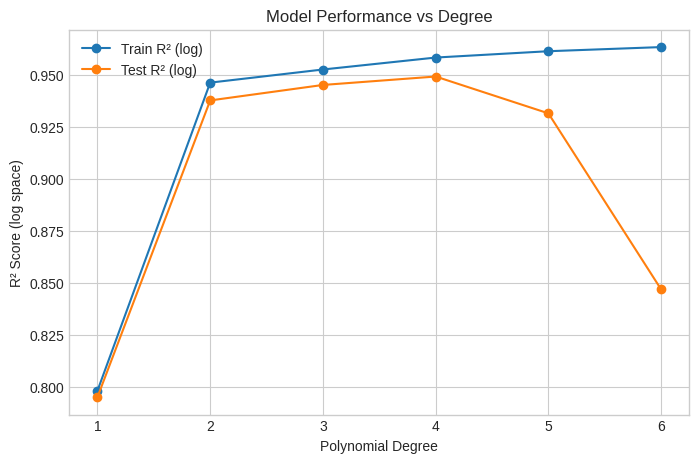


Best degree found: 6

--- Ridge Regression ---


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07033e-16): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Best Ridge Alpha: 0.0000, RMSE: 1.7917

--- Lasso Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.263e+01, tolerance: 8.963e+00
  model = cd_fast.enet_coordinate_descent(


Best Lasso Alpha: 0.0038, RMSE: 2.0314


In [50]:
# Inputs: X_train, X_test, y_reg_train, y_reg_test (defined)

# 1. Polynomial Experiment
find_best_polynomial_degree(X_train, X_test, y_reg_train, y_reg_test, RANDOM_STATE)

# 2. Manual Decision for Best Degree
best_degree = 4

# 3. Regularization
best_ridge_alpha, best_lasso_alpha, ridge_rmse, lasso_rmse = find_best_regularization_alpha(
    X_train, X_test, y_reg_train, y_reg_test, best_degree, RANDOM_STATE
)

# Cross-Validation For Polynomial Regression


--- 5-Fold Cross Validation (Degree=4) ---
Fold RMSEs: [0.1675545  0.14958309 0.15356482 0.14511492 0.17359224]
Mean RMSE: 0.1579


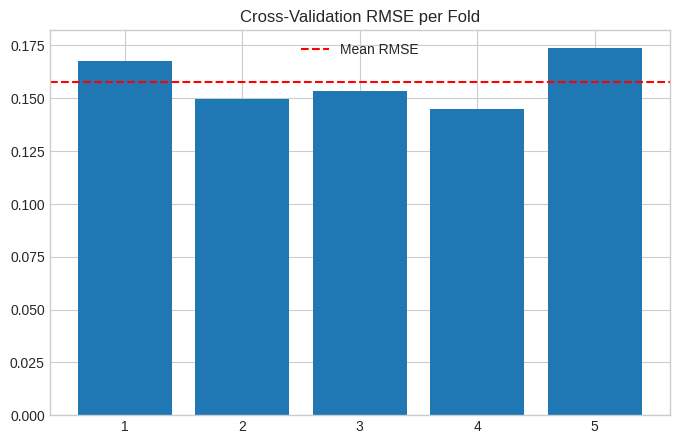

In [51]:
# 4. Cross-Validation Model Selection
if ridge_rmse < lasso_rmse:
    best_model_type = 'Ridge'
    best_alpha = best_ridge_alpha
else:
    best_model_type = 'Lasso'
    best_alpha = best_lasso_alpha

# 5. Cross-Validation
perform_kfold_cv(X_train, y_reg_train, best_degree, best_alpha, best_model_type, RANDOM_STATE)

In [52]:
# # 6. Analysis
# print("\n=== Analysis and Discussion ===")
# print(f"The best model was Polynomial Regression (Degree {best_degree}) with {best_model_type} regularization.")
# print("Ridge performed better because it handles one-hot encoded features by shrinking them smoothly.")

# Naive bayes

--- GaussianNB (Numerical Only) ---
Accuracy:  0.8500
Precision: 0.8473
Recall:    0.8500
F1-Score:  0.8470



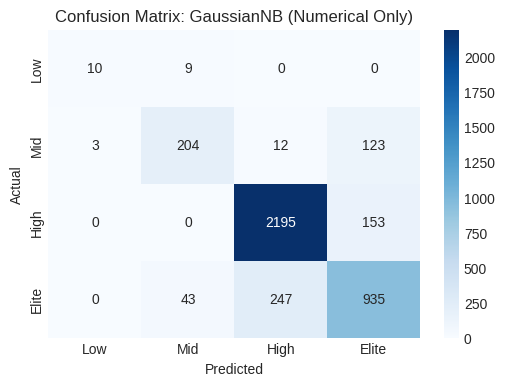

--- BernoulliNB (Full Set) ---
Accuracy:  0.7110
Precision: 0.7274
Recall:    0.7110
F1-Score:  0.6915



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


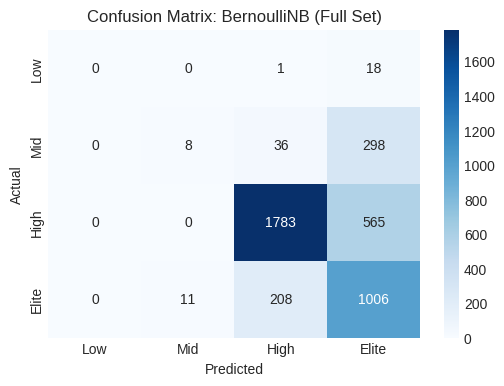

--- ComplementNB (Full Set) ---
Accuracy:  0.8012
Precision: 0.7415
Recall:    0.8012
F1-Score:  0.7673



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


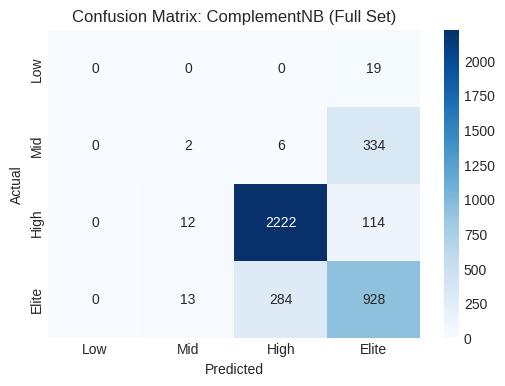

In [53]:
# 1. Initialize the models
models = {
    "GaussianNB (Numerical Only)": GaussianNB(),
    "BernoulliNB (Full Set)": BernoulliNB(),
    "ComplementNB (Full Set)": ComplementNB()
}

# According to requirements: Gaussian should only use numerical features
# (Age, Future Potential, Total_Stats Score)
# These are the first 3 indices in your processed array
X_train_num_only = X_train_clf[:, :3]
X_test_num_only = X_test_clf[:, :3]

# 2. Train and Evaluate each model
for name, model in models.items():
    if "Gaussian" in name:
        model.fit(X_train_num_only, y_clf_train)
        y_pred = model.predict(X_test_num_only)
    elif "Complement" in name:
        # ComplementNB requires non-negative values;
        # Since we used StandardScaler (which centers at 0), we shift to non-negative
        X_train_shifted = X_train_clf - X_train_clf.min()
        X_test_shifted = X_test_clf - X_train_clf.min()
        model.fit(X_train_shifted, y_clf_train)
        y_pred = model.predict(X_test_shifted)
    else:
        model.fit(X_train_clf, y_clf_train)
        y_pred = model.predict(X_test_clf)

    # Metrics
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # 3. Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Logistic Regression

--- Logistic Regression (lbfgs) ---
Accuracy:  0.8874
Precision: 0.8862
Recall:    0.8874
F1-Score:  0.8864



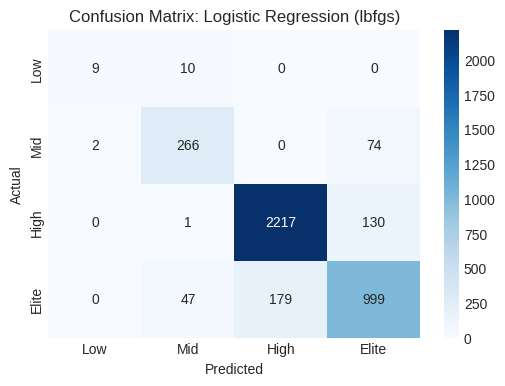

--- Logistic Regression (saga) ---
Accuracy:  0.8871
Precision: 0.8859
Recall:    0.8871
F1-Score:  0.8861



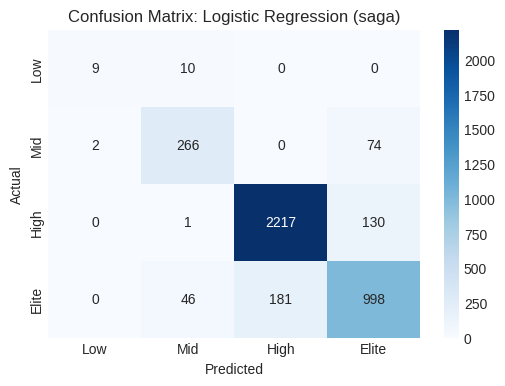

--- Logistic Regression (liblinear) ---
Accuracy:  0.8610
Precision: 0.8546
Recall:    0.8610
F1-Score:  0.8524



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


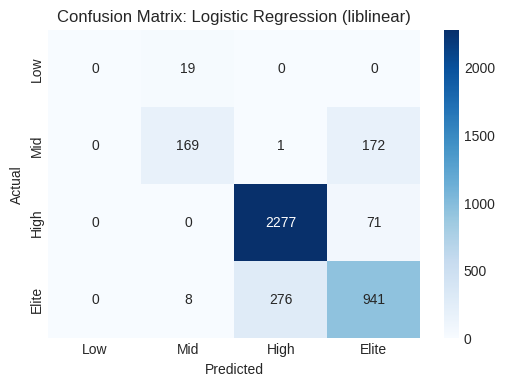

In [54]:
# Logistic Regression with different solvers
models_lr = {
    "Logistic Regression (lbfgs)": LogisticRegression(max_iter=1000, random_state=42),
    "Logistic Regression (saga)": LogisticRegression(max_iter=1000, solver='saga', random_state=42),
    "Logistic Regression (liblinear)": OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
}

for name, model in models_lr.items():
    model.fit(X_train_clf, y_clf_train)
    y_pred = model.predict(X_test_clf)

    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()